# orthophotos-downloader: Step-by-Step Demo

In [1]:
import geopandas as gpd

## 1. Load the Geoshape of the Area You Want to Download

/home/dgodin/documents/projects/orthophotos-downloader/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


<Axes: >

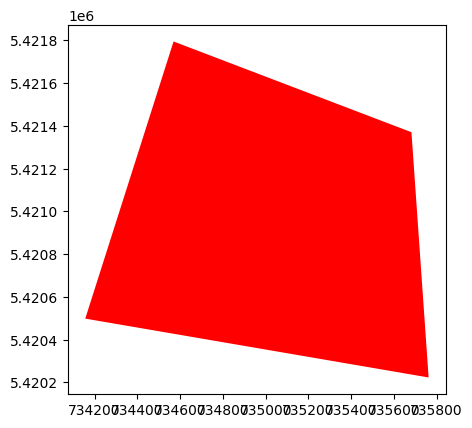

In [2]:
plz = gpd.read_file('data/test_area.geojson', driver='GeoJSON') # A small area in Germany
plz['area'] = plz.geometry.area

area_of_interest = plz['geometry']
area_of_interest = area_of_interest.reset_index(drop=True)
area_of_interest.plot(color='red')

## 2. (Optional) We have implemented a feature that allows you to pass a mask to the image downloader in addition to the area shape. This way, you will only download images in the areas that overlap with the given mask. ##
1. This is optional if you dont give the mask when coalling the download function it will download all images in the area
2. As example we load a mask which countains information on area with building in Bavaria, so we will only download orthophotos in the area that also countains buildings

<Axes: >

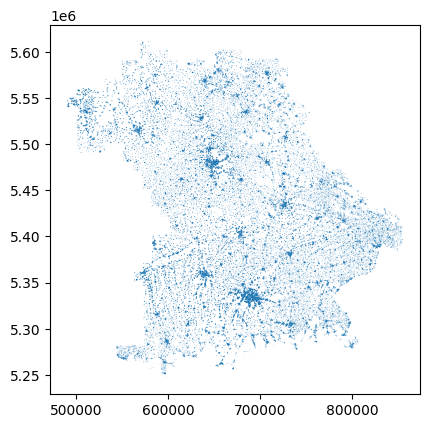

In [3]:
building_mask = gpd.read_file('data/building_mask_bayern_census_buffer_100.geojson').geometry
building_mask = building_mask.reset_index(drop=True)
building_mask.plot()

## 3. Now that we have loaded the area geoinformation and the optional mask, the next step is to instantiate the image downloader. ##
Currently, downloaders are available for two regions: Bavaria and Baden-Württemberg. There is also one for the whole of Germany based on the WMS service from the [BKG](https://gdz.bkg.bund.de/index.php/default/webdienste/digitale-orthophotos/wms-digitale-orthophotos-bodenauflosung-20-cm-wms-dop.html). However, to use it, you will need to contact them to get paid access and a UUID, which you can then use with this library to download the images via Python.

In the future, we plan to automatically instantiate the downloader necessary for your area. For now, you will have to manually instantiate the one that covers your download area. Here, we will instantiate the one for Bavaria.

In [4]:
from pathlib import Path

In [9]:
# Parameters for the downloader
TILE_SIZE = 1000  # tile size in meters -> the are will be divided in squared images of size TILE_SIZE * TILE_SIZE
BUFFER_SIZE = 250  # buffer size in meters -> buffer used to scrap all images at the border of the area and the computed grid -> see next steps
# to save the images
AREA_NAME = 'TOF_MV'
OUT_PATH = Path(f'data/{AREA_NAME}/test_datascraping')

In [10]:
from orthophotos_downloader.data_scraping.wms_germany import BY_RGB_Dop40_ImageDownloader

In [11]:
downloader = BY_RGB_Dop40_ImageDownloader(grid_spacing=TILE_SIZE)

## 4. (Optional) Display the Grid Used to Split the Area into Squared Images ##
In orthophotos-downloader, we first divide the given area into a grid to download multiple squared images. You can check out the grid using this code. In black, you can see the masking (if you used a mask). Only the tiles that intersect with the mask will be downloaded.

<Axes: >

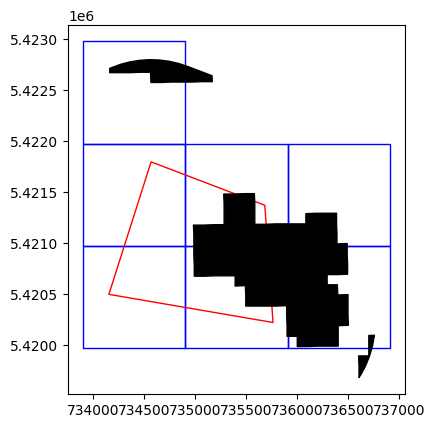

In [12]:
ax = downloader._make_grid(
    area_polygon=area_of_interest.geometry.iloc[0], buffer_size=BUFFER_SIZE, grid_spacing=TILE_SIZE
).plot(facecolor='none', edgecolor='blue')
area_of_interest.plot(ax=ax, facecolor='none', edgecolor='red')

# buffer the area_of_interest and plot the intersection with the building_mask
building_mask.intersection(area_of_interest.buffer(TILE_SIZE)).plot(ax=ax, facecolor='black', edgecolor='black')

## 5. Download the Images

In [13]:
result = downloader.download_images_from_polygon(
    area_name=AREA_NAME,
    area_polygon=area_of_interest.geometry,
    buffer_size=BUFFER_SIZE,
    out_path=OUT_PATH,
)

times = [img.download_time for img in result.images]

print(
    f"Downloaded {len(result.images)} images in {sum(times):.2f} seconds. Average: {sum(times) / len(result.images):.2f} seconds per image."
)

[2026-03-11 16:06:03 - INFO - orthophotos_downloader.data_scraping.image_download] Downloading 7 images for TOF_MV...
[2026-03-11 16:06:03 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 1 of 7...
[2026-03-11 16:06:13 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 1 in 9.40 seconds.

[2026-03-11 16:06:13 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 2 of 7...
[2026-03-11 16:06:22 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 2 in 8.94 seconds.

[2026-03-11 16:06:22 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 3 of 7...
[2026-03-11 16:06:30 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 3 in 8.87 seconds.

[2026-03-11 16:06:30 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 4 of 7...
[2026-03-11 16:06:40 - I

The images are written with the geolocation in the metadata. Alternatively, you can directly use the returned AreaDataset object (in our examples, “results”) and access the .images field to get the list of paths of downloaded images along with the geoinformation.

In [14]:
result.images

[Image(image_path=PosixPath('data/TOF_MV/test_datascraping/image_32_733906_5419973.tiff'), mask_path=None, upper_left_x=733906.0, upper_left_y=5420973.0, download_time=9.400466832999882, width_m=1000.0, height_m=1000.0, width_px=2500, height_px=2500, resolution_m=0.4, crs='EPSG:25832'),
 Image(image_path=PosixPath('data/TOF_MV/test_datascraping/image_32_733906_5420973.tiff'), mask_path=None, upper_left_x=733906.0, upper_left_y=5421973.0, download_time=8.936234295999384, width_m=1000.0, height_m=1000.0, width_px=2500, height_px=2500, resolution_m=0.4, crs='EPSG:25832'),
 Image(image_path=PosixPath('data/TOF_MV/test_datascraping/image_32_733906_5421973.tiff'), mask_path=None, upper_left_x=733906.0, upper_left_y=5422973.0, download_time=8.868435381999006, width_m=1000.0, height_m=1000.0, width_px=2500, height_px=2500, resolution_m=0.4, crs='EPSG:25832'),
 Image(image_path=PosixPath('data/TOF_MV/test_datascraping/image_32_734906_5419973.tiff'), mask_path=None, upper_left_x=734906.0, upper_